In [1]:
print("hello world")

hello world


In [3]:
import pandas as pd

orders=pd.read_csv(r"C:\Users\User\OneDrive\Documents\excel dashboard\orders.csv")
products=pd.read_csv(r"C:\Users\User\OneDrive\Documents\excel dashboard\products.csv")
customers=pd.read_csv(r"C:\Users\User\OneDrive\Documents\excel dashboard\customers.csv")

orders.head(2)


,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion
0,1,C037,67,5,24-02-2023,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary
1,2,C019,41,2,07-11-2023,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali


In [4]:
products.head(2)


,Product_ID,Product_Name,Category,Price (INR),Occasion,Description
0,1,Magnam Set,Soft Toys,1935,All Occasions,Quam numquam iste sunt nemo.
1,2,Voluptas Box,Plants,441,Valentine's Day,At quaerat animi nemo.


In [41]:
customers.head(20)

,Customer_ID,Name,City,Contact_Number,Email,Gender,Address
0,C001,Tara Krishnan,Panchkula,917193971454,mandrati@chad.org,Female,"65/04\nDhawan Marg, Rajpur Sonarpur 590551"
1,C002,Myra Edwin,Bulandshahr,8915420519,yshukla@hotmail.com,Female,H.No. 78\nSharaf Ganj\nIndore 928261
2,C003,Jayesh Lanka,Bilaspur,7400208126,kavyabarad@hotmail.com,Male,"H.No. 53, Krishna Ganj, Dhule-346480"
3,C004,Tarini Bava,Miryalaguda,7232349928,vsen@hotmail.com,Male,"145\nSibal, Rourkela-650344"
4,C005,Hiran Kaul,Kottayam,2207644242,hanshkapur@buch.biz,Male,34/168\nSachar Street\nBhatpara 002691
5,C006,Rania Mann,Karimnagar,919363577179,evaswamy@biswas-sekhon.com,Female,"15/89, Dayal Chowk, Rohtak 586046"
6,C007,Jayant Kamdar,Berhampore,918576675504,pcontractor@hotmail.com,Male,"H.No. 501\nGoswami Path, Bhilwara 482554"
7,C008,Veer Ray,Chinsurah,7138085704,uthkarshjohal@yahoo.com,Female,"H.No. 589, Gala Circle, Nandyal-774484"
8,C009,Ritvik Borah,Madurai,1336765676,daliajivika@yahoo.com,Female,"28/64\nLanka Marg, Ramgarh 141634"
9,C010,Darshit Dave,Kanpur,1608833065,fateh26@hotmail.com,Male,H.No. 21\nSinghal Path\nHindupur 170985


In [6]:
order_products=pd.merge(orders,products, on="Product_ID")

In [7]:
order_products.head()

,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion_x,Product_Name,Category,Price (INR),Occasion_y,Description
0,1,C037,67,5,24-02-2023,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary,Maiores Box,Raksha Bandhan,1374,Anniversary,Earum quos enim minima.
1,2,C019,41,2,07-11-2023,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali,Aut Box,Sweets,1977,Diwali,Ab quisquam nobis ducimus.
2,3,C029,67,5,14-07-2023,19:12:03,19-07-2023,17:39:00,Bilaspur,Anniversary,Maiores Box,Raksha Bandhan,1374,Anniversary,Earum quos enim minima.
3,4,C012,14,5,10-07-2023,04:44:29,19-07-2023,06:33:23,Guwahati,Birthday,Deserunt Box,Colors,1915,Birthday,Incidunt hic vero esse saepe illum.
4,5,C078,58,2,11-02-2023,19:44:48,18-02-2023,11:08:52,Rajkot,Valentine's Day,Sed Pack,Cake,1492,Valentine's Day,Reiciendis nam omnis vel explicabo amet perfer...


In [8]:
full_data=pd.merge(order_products,customers, on="Customer_ID")

In [9]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        1000 non-null   int64 
 1   Customer_ID     1000 non-null   object
 2   Product_ID      1000 non-null   int64 
 3   Quantity        1000 non-null   int64 
 4   Order_Date      1000 non-null   object
 5   Order_Time      1000 non-null   object
 6   Delivery_Date   1000 non-null   object
 7   Delivery_Time   1000 non-null   object
 8   Location        1000 non-null   object
 9   Occasion_x      1000 non-null   object
 10  Product_Name    1000 non-null   object
 11  Category        1000 non-null   object
 12  Price (INR)     1000 non-null   int64 
 13  Occasion_y      1000 non-null   object
 14  Description     1000 non-null   object
 15  Name            1000 non-null   object
 16  City            1000 non-null   object
 17  Contact_Number  1000 non-null   int64 
 18  Email    

In [12]:
full_data["revenue"]=full_data["Quantity"] * full_data["Price (INR)"]

In [13]:
total_revenue=full_data["revenue"].sum()

In [14]:
print("total_revenue",total_revenue)

total_revenue 3520984


In [15]:
total_orders=full_data["Order_ID"].nunique()

In [16]:
print("total_orders",total_orders)

total_orders 1000


In [17]:
average_order=total_revenue/total_orders

In [18]:
print(average_order)

3520.984


In [20]:
top_products=full_data.groupby("Product_Name")["revenue"].sum().sort_values(ascending=False).head(5)

In [21]:
print(top_products)

Product_Name
Magnam Set      121905
Quia Gift       114476
Dolores Gift    106624
Harum Pack      101556
Deserunt Box     97665
Name: revenue, dtype: int64


In [22]:
top_customers=full_data.groupby("Customer_ID")["revenue"].sum().sort_values(ascending=False).head(5)

In [23]:
print(top_customers)

Customer_ID
C020    75029
C044    70409
C045    61294
C024    59666
C099    53082
Name: revenue, dtype: int64


In [25]:
full_data["Order_Date"]=pd.to_datetime(full_data["Order_Date"],dayfirst=True)

In [26]:
monthly_revenue=full_data.groupby(full_data["Order_Date"].dt.to_period("M"))["revenue"].sum()

In [27]:
print(monthly_revenue)

Order_Date
2023-01     95468
2023-02    704509
2023-03    511823
2023-04    140393
2023-05    150346
2023-06    157913
2023-07    135826
2023-08    737389
2023-09    136938
2023-10    151619
2023-11    449169
2023-12    149591
Freq: M, Name: revenue, dtype: int64


In [28]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'monthly_revenue'}, xlabel='Order_Date'>

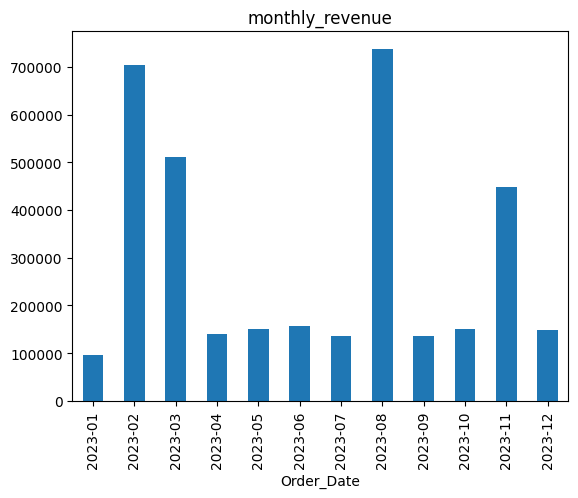

In [29]:
monthly_revenue.plot(kind="bar",title="monthly_revenue")

# KPI Summary Report

## Revenue KPIs

**Total Revenue**=3520984

**Total Orders**=1000

**Average Order**=3520.984

## Top 5 ProductsByName

Magnam Set   
Quia Gift     
Dolores Gift   
Harum Pack    
Deserunt Box   


## Top 5 Customers



C020    
C044   
C045    
C024    
C099   

# Monthly revnue




<Axes: title={'center': 'monthly_revenue'}, xlabel='Order_Date'>

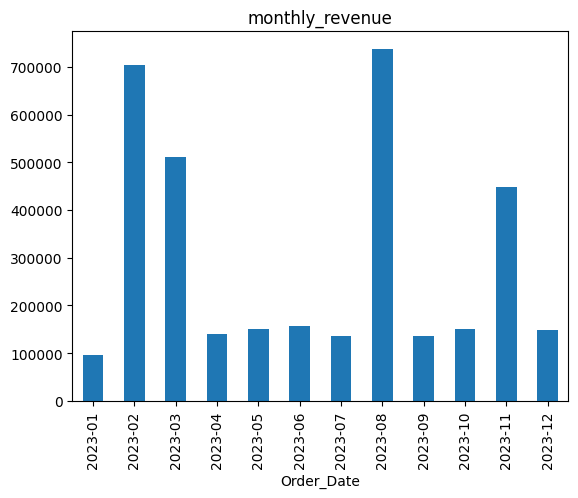

In [38]:
monthly_revenue.plot(kind="bar",title="monthly_revenue")

## Buisness Insights
### highest sales in August
### top category is sweets
### Samaira Ganesh is our top customer
